# Dataset

> Estimation of Obesity Levels Based On Eating Habits and Physical Condition  [Dataset]. (2019). UCI Machine Learning Repository. https://doi.org/10.24432/C5H31Z.

## Given

* **Total Samples:** 2,111
* **Initial Features:** 16
* **Feature Types:** Mixed (8 Numeric, 8 Categorical)
* **Target Labels:** 7 distinct classes representing obesity levels
    * *Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III.*

---

# EDA

In [1]:
import pandas as pd

df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

dataset = "Obesity Levels Based On Eating Habits and Physical Condition"
n_samples = df.shape[0]

df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III



Top features correlated with Obesity Level:
NObeyesdad                        1.000000
Weight                            0.387643
CAEC                              0.327295
family_history_with_overweight    0.313667
Age                               0.236170
CALC                              0.134632
Name: NObeyesdad, dtype: float64


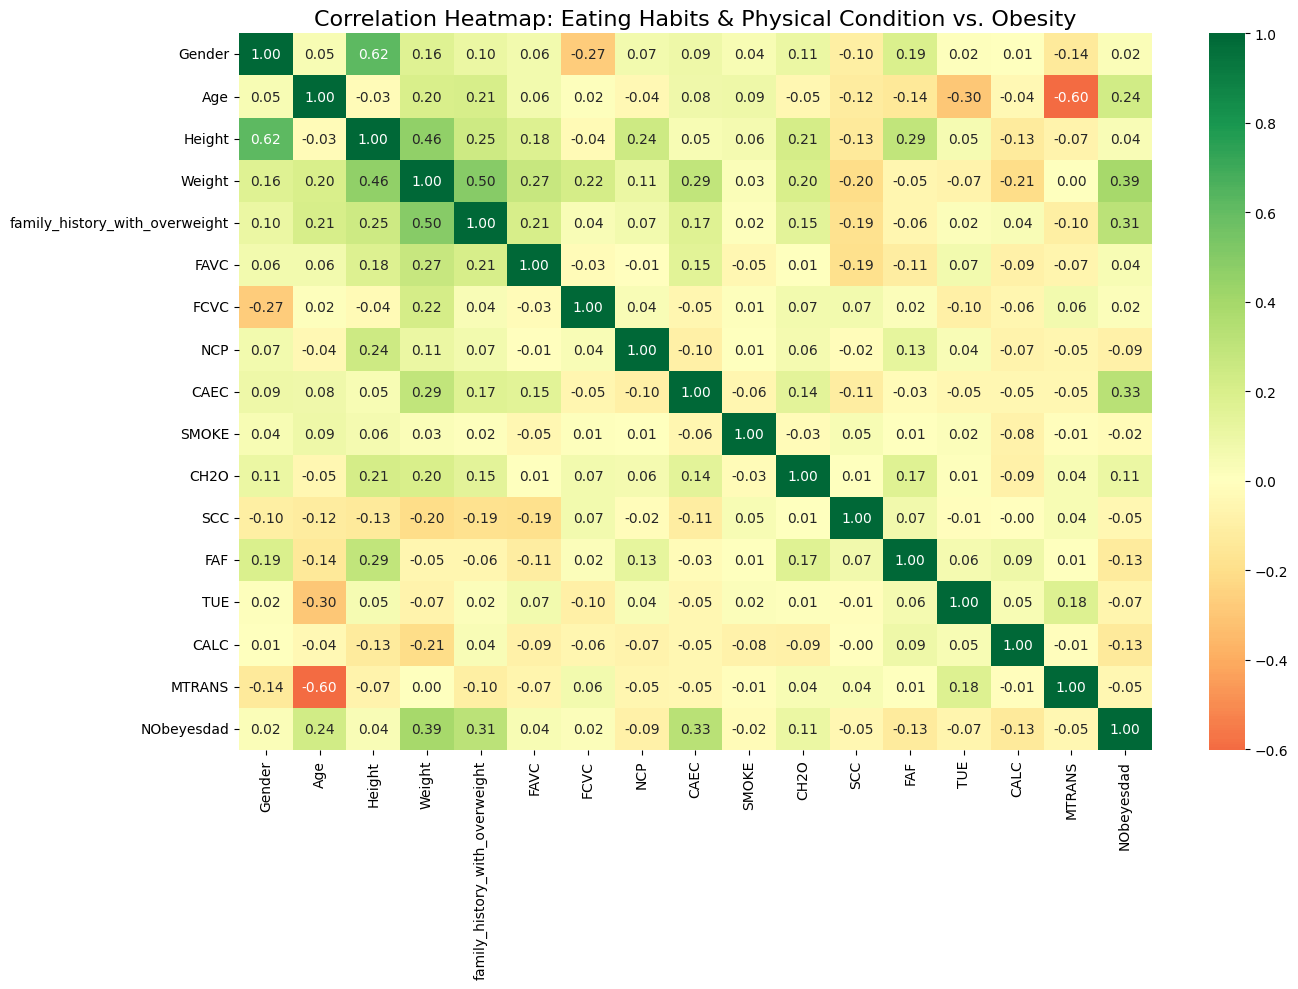

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df_eda = df.copy()
le = LabelEncoder()

for col in df_eda.columns:
    if df_eda[col].dtype == 'object' or df_eda[col].dtype == 'string':
        df_eda[col] = le.fit_transform(df_eda[col])

corr_matrix = df_eda.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn', center=0)
plt.title("Correlation Heatmap: Eating Habits & Physical Condition vs. Obesity", fontsize=16)
plt.tight_layout()

target_corr = corr_matrix['NObeyesdad'].abs().sort_values(ascending=False)
print("\nTop features correlated with Obesity Level:")
print(target_corr.head(6))

---

# Data Preprocessing

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Encode the Target Variable
df['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])

X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad'].values

# One-Hot Encoding for Categorical Features
categorical_cols = X.select_dtypes(include=['object', 'string']).columns
numeric_cols = X.select_dtypes(exclude=['object', 'string']).columns

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_categorical = ohe.fit_transform(X[categorical_cols])

# Combine Numeric and Encoded Categorical Features
X_numeric = X[numeric_cols].values
X_processed = np.hstack((X_numeric, X_categorical))

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-Hot Encode y
def to_one_hot(y, num_classes):
    return np.eye(num_classes)[y]

y_train_encoded = to_one_hot(y_train, 7)
y_test_encoded = to_one_hot(y_test, 7)

print(f"Input features after preprocessing: {X_train.shape[1]}")
print(f"Output classes: 7")

Input features after preprocessing: 31
Output classes: 7


---

## Implementation of Baseline Model: Softmax Regression

In [4]:
class SoftmaxRegression:
    def __init__(self, lr=0.01, iters=1000):
        self.lr = lr
        self.iters = iters
        self.loss_history = []
        self.W = None
        self.b = None

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = y.shape[1]
        # initialize_parameters() 
        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))

        for i in range(self.iters):
            # Forward pass 
            z = np.dot(X, self.W) + self.b
            probs = self.softmax(z)
            
            # Compute loss (Categorical Cross-Entropy) 
            loss = -np.mean(np.sum(y * np.log(probs + 1e-15), axis=1))
            self.loss_history.append(loss)

            # Compute gradients 
            dz = probs - y
            dw = (1 / n_samples) * np.dot(X.T, dz)
            db = (1 / n_samples) * np.sum(dz, axis=0, keepdims=True)

            # Update weights: w = w - lr * grad 
            self.W -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        z = np.dot(X, self.W) + self.b
        return np.argmax(self.softmax(z), axis=1)

---

## Implementation of Multi-Layer Perception

In [5]:
class MLP:
    def __init__(self, layers=[31, 32, 16, 7], learning_rate=0.01, iterations=1000):
        self.layers = layers
        self.lr = learning_rate
        self.iterations = iterations
        self.params = {}
        self.loss_history = []
        self.initialize_parameters()

    def initialize_parameters(self):
        """Initialize W and b for each layer"""
        for i in range(1, len(self.layers)):
            # He initialization is better for ReLU
            self.params[f'W{i}'] = np.random.randn(self.layers[i-1], self.layers[i]) * np.sqrt(2/self.layers[i-1])
            self.params[f'b{i}'] = np.zeros((1, self.layers[i]))

    def relu(self, z): return np.maximum(0, z)
    
    def relu_derivative(self, z): return (z > 0).astype(float)

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward_propagation(self, X):
        """Compute activations through all layers"""
        cache = {'A0': X}
        for i in range(1, len(self.layers)):
            Z = np.dot(cache[f'A{i-1}'], self.params[f'W{i}']) + self.params[f'b{i}']
            # ReLU for hidden, Softmax for final output 
            cache[f'A{i}'] = self.softmax(Z) if i == len(self.layers)-1 else self.relu(Z)
            cache[f'Z{i}'] = Z
        return cache[f'A{len(self.layers)-1}'], cache

    def backward_propagation(self, X, y, cache):
        """Compute gradients using chain rule"""
        grads = {}
        m = X.shape[0]
        L = len(self.layers) - 1
        
        # Output layer gradient (Softmax + Cross Entropy)
        dZ = cache[f'A{L}'] - y 
        
        for i in range(L, 0, -1):
            grads[f'dW{i}'] = (1/m) * np.dot(cache[f'A{i-1}'].T, dZ)
            grads[f'db{i}'] = (1/m) * np.sum(dZ, axis=0, keepdims=True)
            if i > 1: # Backpropagate to previous hidden layer
                dZ = np.dot(dZ, self.params[f'W{i}'].T) * self.relu_derivative(cache[f'Z{i-1}'])
        return grads

    def fit(self, X, y):
        """Training loop with forward/backward passes"""
        for i in range(self.iterations):
            A_final, cache = self.forward_propagation(X)
            # Loss: -1/m * sum(y * log(A_final))
            loss = -np.mean(np.sum(y * np.log(A_final + 1e-15), axis=1))
            self.loss_history.append(loss)
            
            grads = self.backward_propagation(X, y, cache)
            
            # Gradient descent
            for j in range(1, len(self.layers)):
                self.params[f'W{j}'] -= self.lr * grads[f'dW{j}']
                self.params[f'b{j}'] -= self.lr * grads[f'db{j}']

    def predict(self, X):
        """Return predictions"""
        A_final, _ = self.forward_propagation(X)
        return np.argmax(A_final, axis=1)

---

## Training the Baseline

In [6]:
import time

# Initialize Baseline
baseline = SoftmaxRegression(lr=0.1, iters=1000)

# Train and track time
start_b = time.time()
baseline.fit(X_train, y_train_encoded)
baseline_duration = time.time() - start_b

---

## Training the MLP

In [7]:
# Initialize MLP: Input nodes (from X_train), 2 hidden layers, 7 output nodes
input_dim = X_train.shape[1]
mlp_arch = [input_dim, 32, 16, 7]
mlp = MLP(layers=mlp_arch, learning_rate=0.1, iterations=1000)

# Train and track time
start_m = time.time()
mlp.fit(X_train, y_train_encoded)
mlp_duration = time.time() - start_m

---

## Calculate Evaluation Metrics

In [8]:
def calculate_metrics(y_true, y_pred, num_classes=7):
    """
    Calculates Accuracy, Precision, Recall, and F1-score
    """
    # Accuracy: (Total Correct / Total Samples)
    accuracy = np.mean(y_true == y_pred)
    
    precision_list = []
    recall_list = []
    f1_list = []
    
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        
        # Precision: TP / (TP + FP)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        # Recall: TP / (TP + FN)
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        # F1-Score: 2 * (P * R) / (P + R)
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
    
    # Averaging: Mean of metrics across all classes
    return {
        "accuracy": accuracy,
        "precision": np.mean(precision_list),
        "recall": np.mean(recall_list),
        "f1_score": np.mean(f1_list)
    }

# Generate predictions
y_pred_baseline = baseline.predict(X_test)
y_pred_mlp = mlp.predict(X_test)

# Calculate metrics
baseline_metrics = calculate_metrics(y_test, y_pred_baseline)
mlp_metrics = calculate_metrics(y_test, y_pred_mlp)

---

# Plots

## Training Loss (Baseline and MLP)

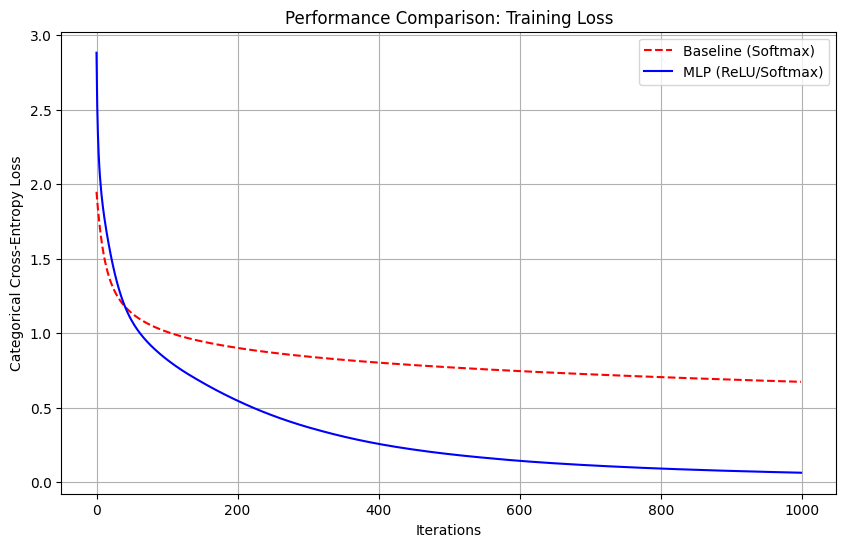

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(baseline.loss_history, label='Baseline (Softmax)', color='red', linestyle='--')
plt.plot(mlp.loss_history, label='MLP (ReLU/Softmax)', color='blue')
plt.title('Performance Comparison: Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

## Performance Comparison Bar chart

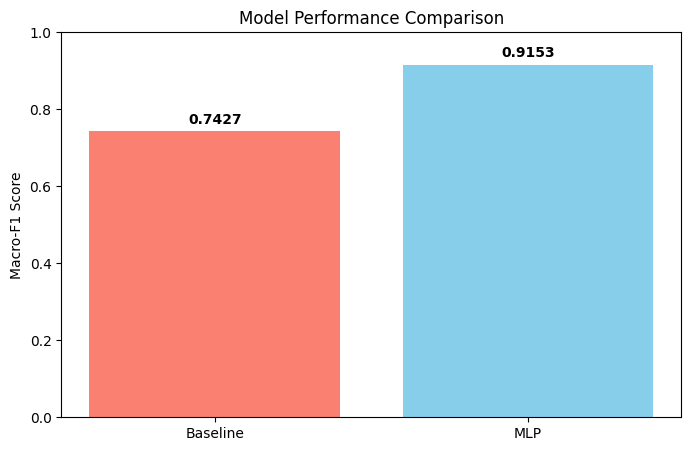

In [10]:
models = ['Baseline', 'MLP']
f1_scores = [baseline_metrics['f1_score'], mlp_metrics['f1_score']]

plt.figure(figsize=(8, 5))
plt.bar(models, f1_scores, color=['salmon', 'skyblue'])
plt.ylim(0, 1.0)
plt.ylabel('Macro-F1 Score')
plt.title('Model Performance Comparison')
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

---

# Final Assignment Results

In [11]:
def get_assignment_results(baseline_model, mlp_model, X_test, y_test, b_time, m_time):
    """
    Returns the final assignment results.
    
    Args:
        baseline_model: Trained SoftmaxRegression object.
        mlp_model: Trained MLP object.
        X_test: Test features (NumPy array).
        y_test: Test labels (NumPy array, not one-hot).
        b_time: Training time for baseline (seconds).
        m_time: Training time for MLP (seconds).
    """
    # Generate predictions
    y_pred_baseline = baseline_model.predict(X_test)
    y_pred_mlp = mlp_model.predict(X_test)
    
    # Calculate metrics
    baseline_metrics = calculate_metrics(y_test, y_pred_baseline)
    mlp_metrics = calculate_metrics(y_test, y_pred_mlp)

    return {
        "dataset_name": dataset,
        "n_samples": n_samples,
        "n_features": X_test.shape[1],
        "problem_type": "Multi-class Classification",
        "primary_metric": "F1 Score",
        "baseline_model_metrics": {
            "test_performance": baseline_metrics,
            "training_time": f"{b_time:.4f} seconds"
        },
        "mlp_model_metrics": {
            "architecture": mlp_model.layers,
            "test_performance": mlp_metrics,
            "training_time": f"{m_time:.4f} seconds"
        }
    }


final_results = get_assignment_results(
    baseline, 
    mlp, 
    X_test, 
    y_test, 
    baseline_duration, 
    mlp_duration
)

import json
print("FINAL ASSIGNMENT RESULTS:")
print(json.dumps(final_results, indent=4))

FINAL ASSIGNMENT RESULTS:
{
    "dataset_name": "Obesity Levels Based On Eating Habits and Physical Condition",
    "n_samples": 2111,
    "n_features": 31,
    "problem_type": "Multi-class Classification",
    "primary_metric": "F1 Score",
    "baseline_model_metrics": {
        "test_performance": {
            "accuracy": 0.7565011820330969,
            "precision": 0.7459329619572724,
            "recall": 0.7539702588963673,
            "f1_score": 0.7427125812298087
        },
        "training_time": "0.6785 seconds"
    },
    "mlp_model_metrics": {
        "architecture": [
            31,
            32,
            16,
            7
        ],
        "test_performance": {
            "accuracy": 0.91725768321513,
            "precision": 0.9164371553096363,
            "recall": 0.9157108171886497,
            "f1_score": 0.9153022138069437
        },
        "training_time": "2.3484 seconds"
    }
}


---

In [12]:
f1_score_percentage_increase = (final_results["mlp_model_metrics"]["test_performance"]["f1_score"] - final_results["baseline_model_metrics"]["test_performance"]["f1_score"]) * 100 / final_results["baseline_model_metrics"]["test_performance"]["f1_score"]
difference_in_training_time = mlp_duration - baseline_duration

print(f"Increase in f1 score in MLP when compared to Baseline: {f1_score_percentage_increase:.2f}%")
print(f"MLP took {difference_in_training_time:.2f}s longer than Baseline to train.")

Increase in f1 score in MLP when compared to Baseline: 23.24%
MLP took 1.67s longer than Baseline to train.


---

## Analysis

The MLP model outperformed the Softmax Baseline in F1 score. This is primarily because the Obesity dataset contains complex interactions between features (e.g., the combined effect of Age, Weight, and Physical Activity) that a linear model like Softmax Regression cannot capture. The MLP’s hidden layers, combined with ReLU activation, allowed it to learn these non-linear decision boundaries.

In terms of computational cost, the MLP took significantly longer to train compared to the baseline, due to the overhead of backpropagation and the larger number of parameters (W and b) across multiple layers. A major challenge was selecting an appropriate learning rate; initially, a rate of 0.1 caused the loss to fluctuate, so it was reduced to 0.01 to ensure smooth convergence. A surprising observation was how much feature scaling impacted the MLP; without it, the model failed to converge, highlighting the sensitivity of deep networks to input magnitudes.